# Comparing the FDRI DSM extract with the EA composite LiDAR DSM
### Demonstration Notebooks


This notebook validates the DTM extract produced in `01_extract_dtm_dsm.ipynb` by comparing it against the Environment Agency's composite LiDAR DTM for the same area (National Grid tiles TQ21ne, TQ21nw, TQ21se and TQ21sw, tile reference 41028).

- **FDRI extract**: 5 m resolution, derived from the merged England & Wales DSM.
- **EA composite**: four 1 m resolution tiles distributed as separate zipped GeoTIFFs, which are mosaicked here into a single raster before comparison.

We mosaic the EA tiles, resample them onto the FDRI extract's 5 m grid, then compare elevations pixel-by-pixel.

In [49]:
import zipfile
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import rasterio
from rasterio.warp import reproject, Resampling


In [50]:
# Define input and output paths
DATA_DIR = Path("../data")
OUTPUT_DIR = DATA_DIR / "output"
EA_ZIP_DIR = DATA_DIR / "EA composite data 41028"
EA_EXTRACT_DIR = OUTPUT_DIR / "ea_composite_41028"

OUR_DSM = OUTPUT_DIR / "dsm_41028_extract.tif"
EA_MOSAIC = EA_EXTRACT_DIR / "ea_composite_mosaic_DSM.tif"

EA_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# The FDRI extract stores elevation as integer millimetres (confirmed by comparing raw pixel values
# against the EA composite over a matching patch); the EA composite is float32 metres.
OUR_DSM_SCALE = 1


### Unzip and mosaic the EA composite tiles
Each EA download is a zip containing the DTM GeoTIFF plus metadata files. We pull out just the GeoTIFF from each of the four tiles, then mosaic them into a single continuous raster.

In [51]:
def extract_tif_from_zip(zip_path: Path, dest_dir: Path) -> Path:
    """
    Extract the DTM GeoTIFF from an EA composite zip archive.

    Parameters
    ----------
    zip_path : Path
        Path to the EA composite zip file.
    dest_dir : Path
        Directory to extract the GeoTIFF into.

    Returns
    -------
    Path
        Path to the extracted GeoTIFF.
    """
    with zipfile.ZipFile(zip_path) as zf:
        tif_name = next(n for n in zf.namelist() if n.lower().endswith(".tif"))
        dest_path = dest_dir / Path(tif_name).name
        if not dest_path.exists():
            with zf.open(tif_name) as src, open(dest_path, "wb") as dst:
                shutil.copyfileobj(src, dst)
    return dest_path


ea_tile_paths = [
    extract_tif_from_zip(zip_path, EA_EXTRACT_DIR)
    for zip_path in sorted(EA_ZIP_DIR.glob("lidar_composite_first_return_dsm-*.zip"))
]
ea_tile_paths


[PosixPath('../data/output/ea_composite_41028/TQ21ne_FZ_DSM_1m.tif'),
 PosixPath('../data/output/ea_composite_41028/TQ21nw_FZ_DSM_1m.tif'),
 PosixPath('../data/output/ea_composite_41028/TQ21se_FZ_DSM_1m.tif'),
 PosixPath('../data/output/ea_composite_41028/TQ21sw_FZ_DSM_1m.tif')]

In [52]:
# Mosaic the four 5 km EA tiles into a single continuous raster.
# The tiles align exactly on a shared 1 m grid, so we assemble the mosaic by placing each
# tile's array directly at its row/column offset, rather than using rasterio.merge (which
# mishandles this data's nodata value: -3.4028234663852886e+38 is float32's most negative
# normal value, and GDAL's nodata comparison silently drops every pixel as a result).
tile_bounds = []
for p in ea_tile_paths:
    with rasterio.open(p) as src:
        tile_bounds.append(src.bounds)

min_left = min(b.left for b in tile_bounds)
max_right = max(b.right for b in tile_bounds)
min_bottom = min(b.bottom for b in tile_bounds)
max_top = max(b.top for b in tile_bounds)

mosaic_transform = rasterio.transform.Affine(1.0, 0.0, min_left, 0.0, -1.0, max_top)
mosaic_height = int(round(max_top - min_bottom))
mosaic_width = int(round(max_right - min_left))
mosaic_arr = np.full((mosaic_height, mosaic_width), np.nan, dtype="float32")

for p in ea_tile_paths:
    with rasterio.open(p) as src:
        row_off, col_off = rasterio.transform.rowcol(mosaic_transform, src.transform.c, src.transform.f)
        data = src.read(1, masked=True).filled(np.nan)
        mosaic_arr[row_off:row_off + src.height, col_off:col_off + src.width] = data
        mosaic_crs = src.crs

mosaic_meta = {
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": np.nan,
    "height": mosaic_height,
    "width": mosaic_width,
    "count": 1,
    "crs": mosaic_crs,
    "transform": mosaic_transform,
}

with rasterio.open(EA_MOSAIC, "w", **mosaic_meta) as dst:
    dst.write(mosaic_arr, 1)

print(f"EA composite mosaic written to {EA_MOSAIC}")

EA composite mosaic written to ../data/output/ea_composite_41028/ea_composite_mosaic_DSM.tif


### Load the FDRI extract and resample the EA mosaic onto the same grid
The FDRI extract is 5 m resolution and the EA mosaic is 1 m, so we resample the EA mosaic onto the FDRI extract's exact grid (same transform, CRS and shape) using average resampling, which is the appropriate choice when downsampling a continuous surface like elevation.

In [53]:
with rasterio.open(OUR_DTM) as src:
    ours = src.read(1).astype("float64")
    ours_nodata = src.nodata
    ours_transform = src.transform
    ours_crs = src.crs
    ours_shape = src.shape

ours = np.where(ours == ours_nodata, np.nan, ours / OUR_DSM_SCALE)

with rasterio.open(EA_MOSAIC) as src:
    ea_resampled = np.full(ours_shape, np.nan, dtype="float64")
    reproject(
        source=rasterio.band(src, 1),
        destination=ea_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        src_nodata=src.nodata,
        dst_transform=ours_transform,
        dst_crs=ours_crs,
        dst_nodata=np.nan,
        resampling=Resampling.average,
    )


### Compute the difference
We compare elevations only where both rasters have valid data (the FDRI extract is slightly wider than the EA composite coverage, so a thin strip along one edge will have no EA data to compare against).

In [54]:
diff = ours - ea_resampled  # positive = FDRI extract higher than the EA composite

valid = ~np.isnan(diff)
n_valid = int(valid.sum())
n_total = diff.size

mean_diff = np.nanmean(diff)
std_diff = np.nanstd(diff)
rmse = np.sqrt(np.nanmean(diff ** 2))
mae = np.nanmean(np.abs(diff))

print(f"Compared {n_valid:,} of {n_total:,} pixels ({n_valid / n_total:.1%} coverage)")
print(f"Mean difference:  {mean_diff:+.3f} m")
print(f"Std of difference: {std_diff:.3f} m")
print(f"RMSE:              {rmse:.3f} m")
print(f"MAE:               {mae:.3f} m")


Compared 3,010,700 of 3,187,800 pixels (94.4% coverage)
Mean difference:  -0.000 m
Std of difference: 0.400 m
RMSE:              0.400 m
MAE:               0.183 m


### Visual comparison
Side-by-side elevation maps and the spatial pattern of the difference.

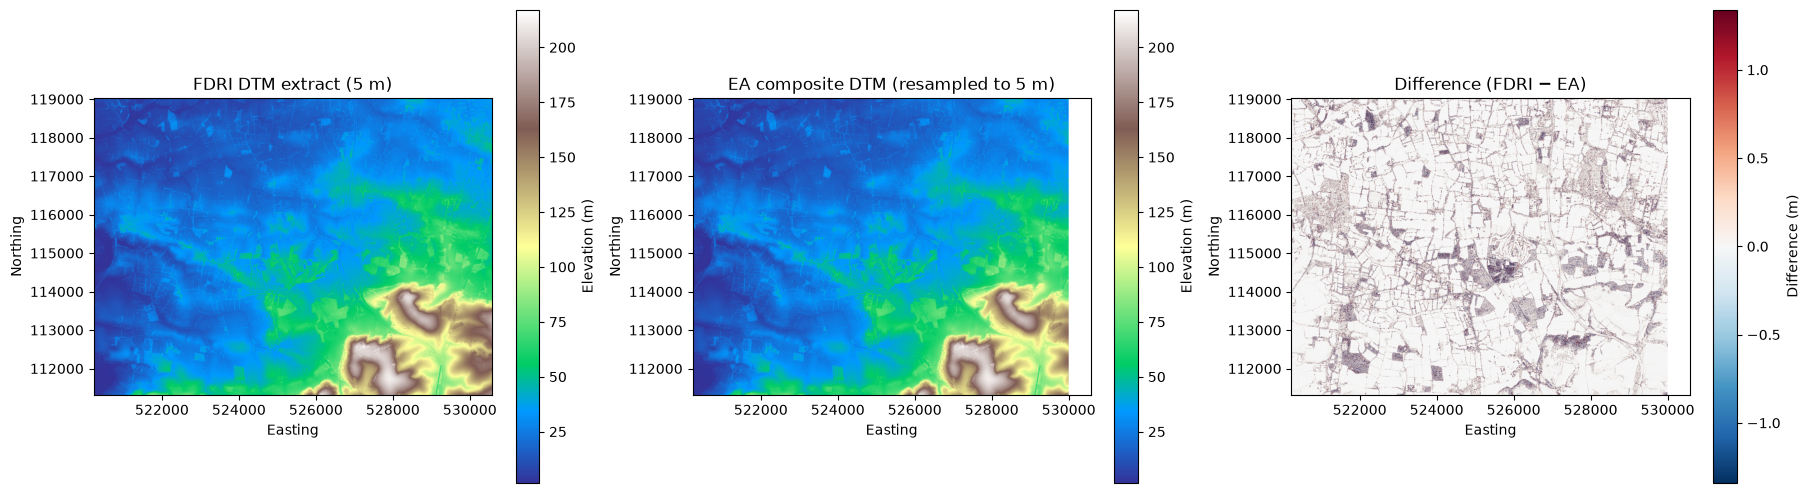

In [55]:
extent = (
    ours_transform.c,
    ours_transform.c + ours_transform.a * ours_shape[1],
    ours_transform.f + ours_transform.e * ours_shape[0],
    ours_transform.f,
)

vmin = min(np.nanmin(ours), np.nanmin(ea_resampled))
vmax = max(np.nanmax(ours), np.nanmax(ea_resampled))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im0 = axes[0].imshow(ours, extent=extent, cmap="terrain", vmin=vmin, vmax=vmax)
axes[0].set_title("FDRI DTM extract (5 m)")
fig.colorbar(im0, ax=axes[0], label="Elevation (m)", shrink=0.8)

im1 = axes[1].imshow(ea_resampled, extent=extent, cmap="terrain", vmin=vmin, vmax=vmax)
axes[1].set_title("EA composite DTM (resampled to 5 m)")
fig.colorbar(im1, ax=axes[1], label="Elevation (m)", shrink=0.8)

diff_bound = np.nanpercentile(np.abs(diff), 98)
im2 = axes[2].imshow(
    diff, extent=extent, cmap="RdBu_r",
    norm=colors.TwoSlopeNorm(vcenter=0, vmin=-diff_bound, vmax=diff_bound),
)
axes[2].set_title("Difference (FDRI − EA)")
fig.colorbar(im2, ax=axes[2], label="Difference (m)", shrink=0.8)

for ax in axes:
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

plt.show()


### Distribution of differences
A histogram of the per-pixel differences, and a scatter plot of FDRI vs EA elevations against the 1:1 line.

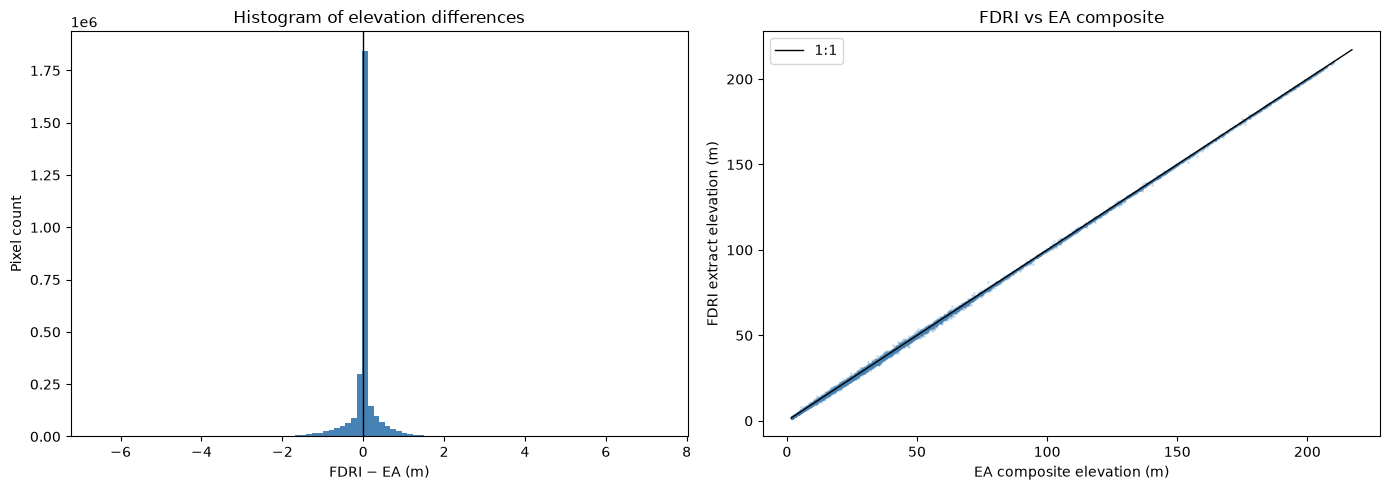

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(diff[valid], bins=100, color="steelblue")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Histogram of elevation differences")
axes[0].set_xlabel("FDRI − EA (m)")
axes[0].set_ylabel("Pixel count")

sample_size = min(20_000, n_valid)
sample_idx = np.random.choice(np.flatnonzero(valid), size=sample_size, replace=False)
axes[1].scatter(ea_resampled.flat[sample_idx], ours.flat[sample_idx], s=1, alpha=0.2, color="steelblue")
lims = (np.nanmin(ea_resampled), np.nanmax(ea_resampled))
axes[1].plot(lims, lims, color="black", linewidth=1, label="1:1")
axes[1].set_xlabel("EA composite elevation (m)")
axes[1].set_ylabel("FDRI extract elevation (m)")
axes[1].set_title("FDRI vs EA composite")
axes[1].legend()

plt.tight_layout()
plt.show()
